# Lab 2: The November Brief
**ADSA 8035, Week 2** | Estimated time: about 3 hours | Due Sunday, September 13, 11:59 PM ET

---

> **From:** Dana Whitmore, Head of Performance
> **To:** you
> **Sent:** Monday, 07:52
>
> Morning. Four soft-tissue injuries in three weeks and the manager mentioned it in the presser, so it is now a thing.
>
> I want an injury-risk feature layer we can all work from, and I want it by Thursday. Right now Priya has a workload spreadsheet, Marcus has a Python script, and Tom has something in Excel from two seasons ago that nobody else can open. On Friday they gave me three different lists of who was at risk. They overlapped on two names.
>
> I need one layer, one owner per feature, and a register that says exactly what each thing is so this stops happening. Definitions are attached from the three of them; I have merged what they agreed on. You build it.
>
> Not everything has to ship this week. Tell me which three features go into the shared layer for Monday's report, which ones wait, and why. Keep the memo short. I will read the first paragraph.
>
> Thursday.

---

That is the lab. You are the analyst. The definitions are below, the way they would be handed to you. The code is yours. The decisions are yours. And Dana reads the first paragraph.

## The Register, As Handed To You

This is what Priya, Marcus and Tom agreed on. Definitions are precise on purpose: two people reading them should build the same number. Where a definition has a **decision** marked, that decision is yours to make and defend.

| Feature | Definition | Decision points |
|---|---|---|
| `days_out` | Return date minus injury date, in days. Rows with impossible dates are flagged and left missing. | none, already built |
| `prior_injuries` | Count of this player's recorded injuries **before** this one, in date order. First recorded injury = 0. | none |
| `days_since_last` | Days between this injury and the same player's previous injury. Missing for a first injury. | **What value do first injuries get, and why?** |
| `first_injury` | 1 if this is the player's first recorded injury in the file, else 0. | none |
| `body_region` | Category derived from the `Injury` text. At minimum: muscle, joint, other. | **Your keyword lists. "Other" must be audited and under 15% of rows.** |
| `form_before` | Mean points from the three matches before the injury: win 3, draw 1, lose 0. Missing matches are skipped, not zero. | none |
| `recurrence` | 1 if this injury is the same `body_region` as the player's previous injury, else 0. First injuries = 0. | none |
| `long_absence` | 1 if `days_out` > 30, else 0. The target for Week 3. | none |

Plus **one feature of your own design**, in Part 4.

## Setup (provided)

Imports, the date parser from the session, the load, and the split. This is infrastructure. Everything after this cell is you.

We split before we build, and the test set stays in the vault. Every feature you build is computed on `x_train` only, and in Week 3 the same function gets applied to the test set without you ever having looked at it.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Set global font size for figures
plt.rcParams.update({'font.size': 12})


def parse_injury_date(value):
    if pd.isna(value):
        return pd.NaT
    text = str(value).strip()
    if text.lower() == "present":
        return pd.NaT
    text = text.replace(",", ", ").replace("  ", " ")
    for fmt in ("%b %d, %Y", "%B %d, %Y"):
        try:
            return pd.to_datetime(text, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT


def add_days_out(df):
    out = df.copy()
    out["injury_date"] = out["Date of Injury"].apply(parse_injury_date)
    out["return_date"] = out["Date of return"].apply(parse_injury_date)
    out["days_out"] = (out["return_date"] - out["injury_date"]).dt.days
    out["date_error"] = (out["days_out"] < 0) | (out["days_out"] > 1000)
    out.loc[out["date_error"], "days_out"] = np.nan
    return out

In [2]:
injury_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1Uaftofu7Ygip2-LOmdyGqQGjK_Ci6QWh", na_values=["N.A."])
injury_df = add_days_out(injury_df)

# Train/test split: the vault stays shut. Everything below uses x_train only.
x_train, x_test = train_test_split(injury_df, test_size=0.25, random_state=42)
x_train = x_train.sort_values(["Name", "injury_date"]).copy()

print("Training rows: " + str(len(x_train)))
print("****************")
print("Rows flagged as date errors in training: " + str(int(x_train["date_error"].sum())))

Training rows: 492
****************
Rows flagged as date errors in training: 1


## Part 1: Prove the Dates Are Clean (15 min)

Before you build anything on top of `days_out`, prove it. A performance director will not check this. You will. Write code that answers all four:

1. What are the shortest and longest absences?
2. Are there any negative absences remaining after the flag?
3. What share of training rows have no usable absence length, and is that the `N.A.` return dates, the flagged errors, or both?
4. Does anything about the longest five absences look wrong to you? Print them with the player name and injury text.

Then answer question 4 in the markdown cell below in one or two sentences.

In [3]:
# TODO: Part 1. Four checks on days_out. Print each one with a label.
print(x_train["days_out"].min(), x_train["days_out"].max())
print((x_train["days_out"] < 0).sum())
print(x_train["days_out"].isna().mean())
print(x_train.nlargest(5, "days_out")[["Name", "Injury", "days_out"]])

2.0 454.0
0
0.008130081300813009
                 Name                  Injury  days_out
287        Phil Jones             Knee injury     454.0
379      Josh Dasilva            Knee surgery     404.0
371        Rico Henry             Knee injury     385.0
474  Giovani Lo Celso          Unknown injury     374.0
126    Calum Chambers  Cruciate ligament tear     315.0


In [4]:
# CHECK: run this after your Part 1 code. It does not give you the answer, it tells you if the ground is solid.
assert (x_train["days_out"].dropna() >= 0).all(), "Negative absences are still in days_out. The flag did not apply."
assert "date_error" in x_train.columns, "date_error column is missing."
print("Part 1 ground is solid: no negative absences, errors are flagged not deleted.")

Part 1 ground is solid: no negative absences, errors are flagged not deleted.


**Your read on the longest five absences (question 4):**

**My take:**
The top four are consistent with known long term injuries like ACL tears. Lo Celco's "unknown injury" 374 is the outlier. The duration matches a serious injury but theres no label. so id flag it rather than assume the text field is reliable. Could be a data entry problem or it was not labeled.


## Part 2: Build the Feature Layer (75 min)

Five features from the register. For each: build it, then run the check cell. The check tells you whether the definition was followed; it does not tell you how.

### 2a. `prior_injuries`

Definition: count of this player's recorded injuries **before** this one, in date order. First recorded injury = 0.

Hint from the session: the arrow of time matters. Sort first. And think about what `groupby` gives you that a plain running count does not.

In [5]:
# TODO: build x_train["prior_injuries"]

x_train["prior_injuries"] = x_train.groupby("Name").cumcount()

In [6]:
# CHECK 2a
if "prior_injuries" in x_train.columns:
    per_player_max = x_train.groupby("Name")["prior_injuries"].max()
    per_player_n = x_train.groupby("Name").size() - 1
    assert x_train["prior_injuries"].min() == 0, "First injuries should be 0."
    assert (per_player_max == per_player_n).all(), "Each player's max prior_injuries should equal their injury count minus one. Did you groupby?"
    first_rows = x_train.groupby("Name").head(1)
    assert (first_rows["prior_injuries"] == 0).all(), "The earliest injury per player must be 0. Is the sort right?"
    print("2a passes. Max prior injuries for one player: " + str(int(x_train["prior_injuries"].max())))
else:
    print("prior_injuries not built yet.")

2a passes. Max prior injuries for one player: 8


### 2b. `days_since_last` and `first_injury`

Definition: days between this injury and the same player's previous injury. Missing for a first injury. `first_injury` is 1 for those rows.

**Decision:** first injuries have no gap. You must choose what value goes in `days_since_last` for them, because the Week 3 model cannot take a blank. The session used a 365-day ceiling. That is one defensible choice. Others: the median gap, a large sentinel like 999, or the player's age in days. Pick one, build it, and defend it in the markdown cell after the check.

The choice matters. A sentinel of 999 tells a model "this player has been healthy forever." A median fill tells it "this player is typical." Those are different claims about players you know nothing about.

In [7]:
# TODO: build x_train["days_since_last"] and x_train["first_injury"]. Apply your chosen fill for first injuries.

x_train["days_since_last"] = x_train.groupby("Name")["injury_date"].diff().dt.days
x_train["first_injury"] = (x_train["prior_injuries"] == 0).astype(int)
x_train["days_since_last"] = x_train["days_since_last"].fillna(365)

In [8]:
# CHECK 2b
if "days_since_last" in x_train.columns and "first_injury" in x_train.columns:
    assert x_train["days_since_last"].notna().all(), "days_since_last still has blanks. First injuries need your fill value."
    assert set(x_train["first_injury"].unique()) <= {0, 1}, "first_injury must be 0 or 1."
    assert (x_train["first_injury"] == (x_train["prior_injuries"] == 0).astype(int)).all(), "first_injury should be 1 exactly when prior_injuries is 0."
    assert (x_train.loc[x_train["first_injury"] == 0, "days_since_last"] >= 0).all(), "Repeat injuries cannot have a negative gap. Check the sort order."
    same_day = int((x_train.loc[x_train["first_injury"] == 0, "days_since_last"] == 0).sum())
    if same_day:
        print("  Note: " + str(same_day) + " repeat injuries have a 0-day gap (same-date records). Real, and worth a line in your memo.")
    print("2b passes. Share of first injuries: " + str(round(x_train["first_injury"].mean(), 3)))
else:
    print("days_since_last / first_injury not built yet.")

2b passes. Share of first injuries: 0.4


**Your fill decision (3 to 4 sentences):** what value did first injuries get, what claim does that make about those players, and what would a physio say if you explained it to them?

**My take:**
First injuries got a flat fill of 365 for days_since_last, since theres no real "days since las injury" to measure for a players first recorded injury. This claims those players are roughly a year removed from any prior injury. This is assumed as a natural middle ground, rather than assuming they're perfectly healthy. I would say that a physio would flag this because it does not distinguish a player whos genuinely never been injured from one whoe earlier injuries just arent in the data set. Id treat 365 as a reasonable, but do call out that it has a limitation.


### 2c. `body_region`

Definition: a category derived from the `Injury` text. At minimum muscle, joint, other. You may add categories.

**Decision:** the keyword lists are yours. The session showed you what falls into "other" when you are lazy about them: concussions, illness, fractures, all in one bin with a ruptured Achilles.

**Requirement:** print what landed in "other," read it, iterate your keywords at least once, and finish with "other" under 15% of training rows. Do not chase it to zero. Some injuries are genuinely unclassifiable from a two-word string, and a fake zero is worse than an honest 12%.

In [9]:
# TODO: build x_train["body_region"]. Print the "other" bucket. Iterate. Show the before and after counts.

def region(t):
    t = str(t).lower()
    if any(k in t for k in ["muscle","hamstring","calf","groin","quad","thigh","adductor","hip flexor","dead leg","tendon"]):
        return "muscle"
    if any(k in t for k in ["knee","ankle","ligament","shoulder","foot","hip","meniscus","toe","elbow","neck","chest"]):
        return "joint"
    if any(k in t for k in ["fracture","rib","arm","hand","facial","back","head","shin","bruise"]):
        return "bone"
    if any(k in t for k in ["corona","virus","flu","ill","infection","malaria","shingles","quarantine","depression","cold"]):
        return "illness"
    return "other"

x_train["body_region"] = x_train["Injury"].apply(region)
print(x_train.loc[x_train["body_region"] == "other", "Injury"].value_counts())
print((x_train["body_region"] == "other").mean())


Injury
Knock                          13
unknown injury                 12
Fitness                         4
concussion                      3
Leg injury                      3
Unknown injury                  3
muscular problems               2
stress reaction of the bone     1
Inflammation of pubic bone      1
broken fibula                   1
fitness                         1
unknown injur                   1
Inflammation bone               1
knock                           1
abdominal problems              1
minor knock                     1
Name: count, dtype: int64
0.09959349593495935


In [10]:
# CHECK 2c
if "body_region" in x_train.columns:
    other_share = (x_train["body_region"] == "other").mean()
    assert {"muscle", "joint"} <= set(x_train["body_region"].unique()), "Need at least muscle and joint categories."
    assert other_share < 0.15, "'other' is " + str(round(other_share, 3)) + " of rows. Iterate your keywords. Read the bucket."
    print("2c passes. 'other' share: " + str(round(other_share, 3)) + "   categories: " + str(sorted(x_train["body_region"].unique())))
else:
    print("body_region not built yet.")

2c passes. 'other' share: 0.1   categories: ['bone', 'illness', 'joint', 'muscle', 'other']


**What was in "other" before you iterated, and what did you do about it (2 to 3 sentences):**

**My take:** before iterating, "other" was 27% of the rows. mostly single-instance body parts (hip, thigh, back, head, chest) that just werent in my keywords lists, plus illness cases like coronavirus and malaria lumped in with real injuries. I broadened the muscle/joint keywords, added "bone" category for fractures and bruises, and separate "illness" category, which brought "other" down to 10%, leaving only genuinely vague entries like "knock" and "unknown injury".

### 2d. `form_before`

Definition: mean points from the three matches before the injury. Win 3, draw 1, lose 0. Missing matches are **skipped, not counted as zero**.

That last clause is the trap. A match that never happened is not a loss. Find the three result columns by pattern rather than by typing their names, because the next file you get will name them differently.

In [11]:
# TODO: build x_train["form_before"]. Discover the result columns by pattern. Skip missing matches.


In [12]:
print(x_train.columns.tolist())

['Name', 'Team Name', 'Position', 'Age', 'Season', 'FIFA rating', 'Injury', 'Date of Injury', 'Date of return', 'Match1_before_injury_Result', 'Match1_before_injury_Opposition', 'Match1_before_injury_GD', 'Match1_before_injury_Player_rating', 'Match2_before_injury_Result', 'Match2_before_injury_Opposition', 'Match2_before_injury_GD', 'Match2_before_injury_Player_rating', 'Match3_before_injury_Result', 'Match3_before_injury_Opposition', 'Match3_before_injury_GD', 'Match3_before_injury_Player_rating', 'Match1_missed_match_Result', 'Match1_missed_match_Opposition', 'Match1_missed_match_GD', 'Match2_missed_match_Result', 'Match2_missed_match_Opposition', 'Match2_missed_match_GD', 'Match3_missed_match_Result', 'Match3_missed_match_Opposition', 'Match3_missed_match_GD', 'Match1_after_injury_Result', 'Match1_after_injury_Opposition', 'Match1_after_injury_GD', 'Match1_after_injury_Player_rating', 'Match2_after_injury_Result', 'Match2_after_injury_Opposition', 'Match2_after_injury_GD', 'Match2_

In [13]:
print(x_train["Match1_before_injury_Result"].unique())

['lose' 'win' 'draw' nan]


In [14]:
pts = {"win": 3, "draw": 1, "lose": 0}
cols = ["Match1_before_injury_Result", "Match2_before_injury_Result", "Match3_before_injury_Result"]
x_train["form_before"] = x_train[cols].apply(lambda r: r.map(pts)).mean(axis=1)

In [15]:
# CHECK 2d
if "form_before" in x_train.columns:
    vals = x_train["form_before"].dropna()
    assert vals.between(0, 3).all(), "form_before must be between 0 and 3."
    assert x_train["form_before"].isna().sum() < len(x_train) * 0.5, "Too many blanks. Are you skipping missing matches or dropping the whole row?"
    print("2d passes. Rows with no usable form: " + str(int(x_train["form_before"].isna().sum())))
else:
    print("form_before not built yet.")

2d passes. Rows with no usable form: 31


### 2e. `recurrence`

Definition: 1 if this injury is the same `body_region` as the player's **previous** injury, else 0. First injuries are 0.

This is the hardest of the five. You need the previous row's value, within player, in date order. Think about what `shift` does inside a `groupby`.

In [16]:
# TODO: build x_train["recurrence"]

x_train["recurrence"] = (x_train["body_region"] == x_train.groupby("Name")["body_region"].shift(1)).astype(int)

In [17]:
# CHECK 2e
if "recurrence" in x_train.columns:
    assert set(x_train["recurrence"].unique()) <= {0, 1}, "recurrence must be 0 or 1."
    assert (x_train.loc[x_train["first_injury"] == 1, "recurrence"] == 0).all(), "First injuries must be 0 for recurrence."
    prev = x_train.groupby("Name")["body_region"].shift(1)
    expected = (x_train["body_region"] == prev).astype(int)
    assert (x_train["recurrence"] == expected).all(), "recurrence does not match the definition. Check your groupby and shift."
    print("2e passes.")
else:
    print("recurrence not built yet.")

2e passes.


### The target

`long_absence` is 1 when `days_out` is over 30. It is not a feature, it is what Week 3 predicts. Build it now so Part 3 can use it.

In [18]:
# TODO: build x_train["long_absence"]

x_train["long_absence"] = (x_train["days_out"] > 30).astype(int)

## Part 3: Prove They Carry Signal (30 min)

A feature earns its place by separating outcomes. For each of the five, show the long-absence rate split by that feature. Numeric features: split at a sensible cutoff or by quartile. Categorical: groupby.

Then pick the **one** feature you would show Dana on a single slide and build that chart. Axis labels, a title that states the finding rather than the variable name, and a one-sentence caption underneath. Ten-second test: if she has to study it, redesign it.

In [19]:
# TODO: long_absence rate split by each of the five features

for col in ["prior_injuries", "days_since_last", "body_region", "form_before", "recurrence"]:
    if x_train[col].dtype == "object" or x_train[col].nunique() < 10:
        print(col)
        print(x_train.groupby(col)["long_absence"].mean())
    else:
        print(col)
        print(x_train.groupby(pd.qcut(x_train[col], 4, duplicates="drop"))["long_absence"].mean())
    print()

prior_injuries
prior_injuries
0    0.446701
1    0.406504
2    0.358974
3    0.500000
4    0.448276
5    0.714286
6    0.857143
7    0.666667
8    0.000000
Name: long_absence, dtype: float64

days_since_last
days_since_last
(6.999, 149.25]    0.398374
(149.25, 365.0]    0.460265
(365.0, 1334.0]    0.432836
Name: long_absence, dtype: float64

body_region
body_region
bone       0.472222
illness    0.071429
joint      0.538462
muscle     0.459330
other      0.346939
Name: long_absence, dtype: float64

form_before
form_before
(-0.001, 1.0]    0.445055
(1.0, 1.333]     0.380952
(1.333, 2.0]     0.427350
(2.0, 3.0]       0.424242
Name: long_absence, dtype: float64

recurrence
recurrence
0    0.424403
1    0.495652
Name: long_absence, dtype: float64



Text(0.5, 0, '')

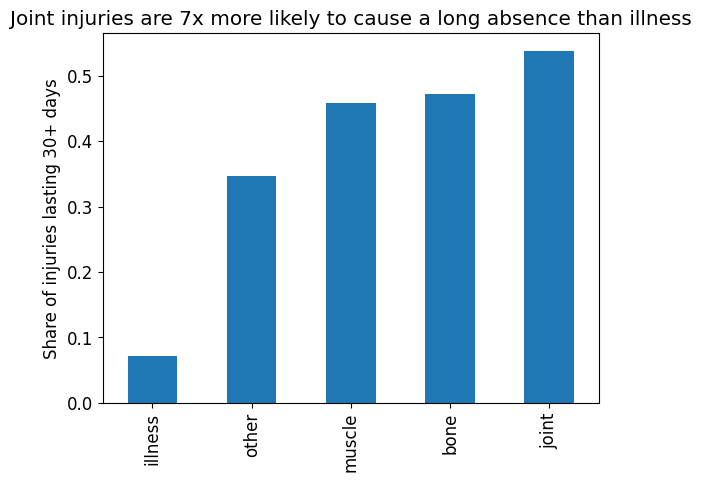

In [20]:
# TODO: the one chart for Dana. Title states the finding. Caption in the markdown cell below.

rates = x_train.groupby("body_region")["long_absence"].mean().sort_values()
ax = rates.plot(kind="bar", title="Joint injuries are 7x more likely to cause a long absence than illness")
ax.set_ylabel("Share of injuries lasting 30+ days")
ax.set_xlabel("")

**Caption (one sentence):**

**My take:** joint injuries (54%) are far more likely to sideline a player for 30+ days than illness (7%), making body region one of the strongest early signals in the layer.

## Part 4: One Feature of Your Own (30 min)

Priya, Marcus and Tom gave you five. Dana wants to know what you would add.

Design one feature that is not in the register. Requirements, in this order:

1. **Sporting logic first**, in the markdown cell below, in one sentence a physio would nod at.
2. Then the code.
3. Then the evidence: long-absence rate split by your feature.
4. Then its register entry in Part 5.

Ideas to steal or ignore: an age band, a season-phase flag (early, congested winter, run-in), a per-club injury count so far this season, whether the club lost the match before the injury, a "serious history" flag for any previous absence over 60 days.

The rule from the session: no time travel. Nothing a club could not know on the day of the injury.

**Sporting logic for your feature (one sentence):**

**My take:** Players with a history of a serious long-term injury (60+ days) are more likely to be at risk again, since old serious injuries often leave lasting weakness or compensation patterns

In [21]:
# TODO: build your feature and show the long-absence rate split by it

prev_long = x_train.groupby("Name")["days_out"].shift(1) > 60
x_train["serious_history"] = prev_long.groupby(x_train["Name"]).cummax().astype(int)

In [22]:
print(x_train["serious_history"].mean())
print(x_train.groupby("serious_history")["long_absence"].mean())

0.22154471544715448
serious_history
0    0.409922
1    0.550459
Name: long_absence, dtype: float64


Players with a history of a serious injury have a 55% long-absence rate vs 41% without, and 22% of rows carry the flag, so it's not a tiny edge case.

<Axes: title={'center': 'Long-absence rate by injury history'}, xlabel='serious_history'>

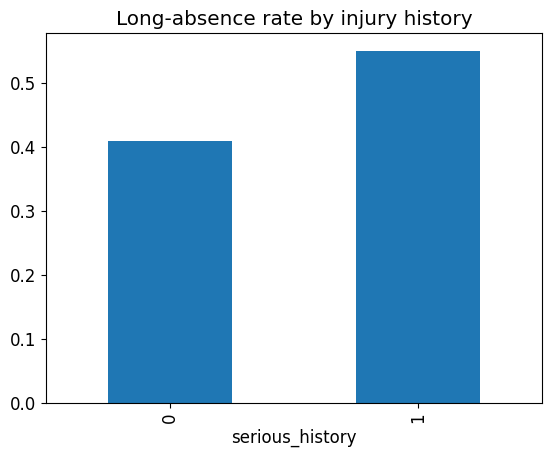

In [23]:
x_train.groupby("serious_history")["long_absence"].mean().plot(kind="bar", title="Long-absence rate by injury history")

## Part 5: The Register (20 min)

This is the deliverable Dana actually keeps. One row per feature, all six. Precise definitions. Named owners. A real failure mode. And the dispute, if there is one, stated out loud rather than hidden.

The "breaks if" column is the one people skip and the one that matters most in March.


| Feature | Definition | Why it exists | Breaks if | Known dispute |
|---|---|---|---|---|
| `prior_injuries` | Count of prior injuries per player, date order. First = 0. | Tracks injury-prone history. | Data not sorted by player/date first. | Treats all injuries as equal severity. |
| `days_since_last` | Days since player's last injury. First injuries filled with 365. | Flags short-gap re-injury risk. | Wrong sort order, inconsistent fill. | 365 fill can't tell "no data" from "healthy." |
| `body_region` | muscle/joint/bone/illness/other from `Injury` text keywords. | Region drives recovery time. | Keywords miss new phrasing, "other" grows. | 10% "other" still hides real injuries. |
| `form_before` | Mean points (W3/D1/L0) from 3 prior matches, skipping missing. | Tests link between form and injury risk. | Missing matches counted as losses. | 31 rows have no usable form at all. |
| `recurrence` | 1 if same `body_region` as player's last injury. | Flags repeat-region injuries. | Wrong shift direction/sort order. | Inherits any `body_region` misclassification. |
| `serious_history` | 1 if any prior injury had `days_out` > 60. | Past serious injury signals future risk. | 60-day threshold or cumulative logic breaks. | 60-day cutoff is arbitrary. |



## Part 6: The Stability Check (15 min)

Every threshold in this layer is a choice. The 30-day target. The 60-day quick re-injury cutoff. Your keyword lists. Pick **one** threshold from your work and show the finding across at least three values of it.

Does the story survive? Say which of the three verdicts from the session applies: sturdy, lucky, or fragile.

In [24]:
# TODO: one threshold, three or more values, the finding at each

for t in [30, 60, 90, 120]:
    prev_long = x_train.groupby("Name")["days_out"].shift(1) > t
    flag = prev_long.groupby(x_train["Name"]).cummax()
    print(t, x_train.groupby(flag)["long_absence"].mean().values)

30 [0.41324921 0.49142857]
60 [0.40992167 0.55045872]
90 [0.42789598 0.52173913]
120 [0.43171806 0.55263158]


**Verdict and why (2 to 3 sentences):**

**Verdict**
At every threshold tested (30, 60, 90, 120 days), players flagged with a serious prior injury had a higher long-absence rate than those without, with the gap ranging from about 8 to 14 percentage points. The finding doesn't depend on picking exactly 60 days.

## Part 7: The Memo to Dana (20 min)

She reads the first paragraph. Structure it so the first paragraph is the answer.

**Paragraph 1:** The three are, body_region, serious_history, and prior_injuries that go into the sahred layer fro Mondays report. body_region showed the cleares split of anything build, joint injuries are over seven times more likely to cuase a 30+ day absence than illness. serious_history held up across every threshold tested, with flagged players running 8 to 14 points higher on long-absence rate. prior_injuries is simple, and already agreed by Priya, Marcus and Tom.

**Paragraph 2:** days_since_last wait on a decision from medical about how to treat players with no injury history, right now first injuries default to a 365-day guess and that need a real call not a random assumption. form_before waits on a better match history feed, since all three prior matches are missing for 31 rows.

**Paragraph 3:** body_region us built from keyword matching on a short injury text, and even after iterating, about 10% still land in an unclassifiable "other" bucket. Since recurrence depends directly on body_region, any misclassification might go into a second feature.

**Paragraph 4 (optional):** One thing that would help is to have a standardized injury-type field at data entry, instead of a free text it would fix the "other" bucket.

Five to eight sentences total. No code. No column names without a plain-language gloss.

## Stretch (optional, not graded, genuinely hard)

Build `injuries_last_365`: for each injury, the number of that player's injuries in the 365 days **before** it. Not a cumulative count. A rolling window on dates.

This is the kind of feature a real workload model uses, and pandas does not make it easy. If you get it working, add it to your register and say in the memo whether it beats `prior_injuries`.

In [25]:
# STRETCH: injuries_last_365


## AI-Use Disclosure (required)

Answer all five, briefly. "I did not use AI this week" is a complete and acceptable answer.

1. What did you use AI for, and with which tools?
- I used AI to help me format the files and brainstorm some lines of code or what was the best approach to tackle the problem. What I mostly use it is to troubleshoot  code errors.
2. What were your most important prompts?
- One thing that i try to use AI and in my promts is to help me simply the code, i feel sometimes im over writting or take longer to get to the point.
3. What did the AI get wrong, or what did you change from its output?
- When trying to create the categories to sort out the injury_region it gav examples which still had over 15% of "other".
4. Where did your human judgment come in: what call did you make that the AI could not?
- In deciding to build the serious_history it has suggested other options for that part 4.
5. What are you still unsure about?
- wether 365 days is really the right fill for first injuries.

*Write here.*

## Submission Checklist

- [ X] Every cell runs top to bottom without errors
- [ X] All seven CHECK cells print a pass
- [ X] The "other" bucket was printed, read, and is under 15%
- [ X] Your fill decision for first injuries is defended in writing
- [ X] Your own feature has sporting logic stated before the code
- [ X] The register has all six rows filled, including "breaks if"
- [ X] The stability check names a verdict
- [ X] The memo's first paragraph names three features
- [ X] AI-Use Disclosure completed
- [ X] Share link set to Anyone with the link, Viewer, tested in an incognito window

## How This Is Graded

| Criterion | Points | What earns full marks |
|---|---|---|
| Feature layer builds to spec | 25 | All five checks pass; code is readable; no time travel |
| Decisions defended | 20 | Fill value, keyword lists, and your own feature each have stated sporting logic |
| Evidence and the chart | 15 | Every feature has a signal check; the one chart passes the ten-second test |
| The register | 20 | Precise definitions, real "breaks if" entries, dispute named |
| The memo | 20 | First paragraph names three features; waits are specific; the dispute is printed |

Not on the rubric: number of plots, length of code, cleverness. On the rubric: decisions, and whether Dana could act on Monday.